# ChemiAI — предсказание противовирусной активности соединений

Ноутбук с решением задачи регрессии по молекулярным дескрипторам: для каждого соединения предсказываются **IC50**, **CC50** и **SI**.

## Описание задачи

Разработка лекарств — длительный процесс синтеза и биологического тестирования. Машинное обучение позволяет оценивать перспективность соединений **до** лабораторных экспериментов.

В датасете — свойства молекул и их активность против вируса гриппа. Нужно построить модель, предсказывающую для новых соединений:

| Таргет | Смысл |
|--------|--------|
| **IC50 (mM)** | концентрация, при которой подавляется 50% активности вируса |
| **CC50 (mM)** | концентрация токсичности для 50% клеток |
| **SI** | индекс селективности (Selectivity Index) |

**Метрика:** среднее RMSE по трём таргетам:

$$\text{score} = \frac{RMSE(IC50) + RMSE(CC50) + RMSE(SI)}{3}$$

**Формат сабмита:** `index, IC50, CC50, SI` (см. `sample_submission.csv`).

Подробнее — в [DESCRIPTION.md](./DESCRIPTION.md). Данные: [Google Drive](https://drive.google.com/drive/folders/1m1PS44rF9HqIAOUZQeopU5sqwgi6YfO8?usp=sharing).

## План работы

1. **Загрузка данных** — скачивание с Google Drive и чтение `train` / `test` / `sample_submission`.
2. **EDA** — распределения таргетов и признаков, пропуски, корреляции.
3. **Предобработка** — масштабирование, отбор признаков при необходимости.
4. **Моделирование** — baseline и улучшенные модели (multi-target или отдельные регрессоры).
5. **Валидация** — кросс-валидация по метрике соревнования.
6. **Сабмит** — предсказания на `test.csv` и сохранение `submission.csv`.

## 1. Настройка окружения

## 1.1 Установка библиотек

In [2]:
import gdown
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

## 1.2 Глобальные переменные

In [3]:
# Воспроизводимость
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Пути
ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data"
GDRIVE_FOLDER_ID = "1m1PS44rF9HqIAOUZQeopU5sqwgi6YfO8"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

## 2. Обработка данных

Датасет: [Google Drive](https://drive.google.com/drive/folders/1m1PS44rF9HqIAOUZQeopU5sqwgi6YfO8?usp=sharing) (`train.csv`, `test.csv`, `sample_submission.csv`).

Сначала делаем структурные проверки (типы, дубли, константы), затем переходим к пропускам и анализу таргетов.

In [4]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

required_files = [TRAIN_PATH, TEST_PATH, SAMPLE_SUBMISSION_PATH]
missing_files = [p for p in required_files if not p.exists()]

# Скачиваем только если локально не хватает нужных файлов.
if missing_files:
    gdown.download_folder(id=GDRIVE_FOLDER_ID, output=str(DATA_DIR))
else:
    print("Данные уже скачаны, повторная загрузка не требуется.")

Данные уже скачаны, повторная загрузка не требуется.


In [5]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print(f"Sample submission: {sample_submission.shape}")
train.head()

Train: (751, 214)
Test:  (250, 211)
Sample submission: (250, 4)


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [6]:
print("\nTrain первые 8 колонок:", train.columns[:8].tolist())
print("Test  первые 8 колонок:", test.columns[:8].tolist())
print("Sample колонки:", sample_submission.columns.tolist())


Train первые 8 колонок: ['index', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex']
Test  первые 8 колонок: ['index', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt']
Sample колонки: ['index', 'IC50', 'CC50', 'SI']


## 2.1 Типы данных

Типы в train:

In [7]:
display(train.dtypes.value_counts())

int64      107
float64    107
Name: count, dtype: int64

Список нечисловых колонок:

In [8]:
non_numeric_train = train.select_dtypes(exclude="number").columns.tolist()
non_numeric_test = test.select_dtypes(exclude="number").columns.tolist()

print("Нечисловые в train:", non_numeric_train)
print("Нечисловые в test :", non_numeric_test)

Нечисловые в train: []
Нечисловые в test : []


В `train` и `test` все признаки числовые, нечисловых столбцов нет.

Распределение типов в `train` сбалансированное: 107 `int64` и 107 `float64` (всего 214 колонок), поэтому кодирование категориальных признаков не требуется и можно сразу применять числовые модели / импутацию.

## 2.2 Проверка расхождения колонок `train` / `test`

In [9]:
# Колонки, которые есть в train, но нет в test
only_in_train = sorted(set(train.columns) - set(test.columns))

# Колонки, которые есть в test, но нет в train
only_in_test = sorted(set(test.columns) - set(train.columns))

print("Только в train:", only_in_train)
print("Только в test:", only_in_test)

Только в train: ['CC50, mM', 'IC50, mM', 'SI']
Только в test: []


In [10]:
TARGET_COLS = ["IC50, mM", "CC50, mM", "SI"]
ID_COL = "index"

FEATURE_COLS = [c for c in train.columns if c not in [ID_COL, *TARGET_COLS]]

X_train = train[FEATURE_COLS].copy()
y_train = train[TARGET_COLS].copy()
X_test = test[FEATURE_COLS].copy()

print(X_train.shape, y_train.shape, X_test.shape)

(751, 210) (751, 3) (250, 210)


## 2.3 Проверка дубликатов и констант

Проверяем качество признакового пространства: ищем дубли строк по признакам, константные и дублирующиеся столбцы. Это нужно, чтобы убрать шум и стабилизировать модель на маленькой выборке.

In [11]:
# Дубли строк по признакам (без таргетов)
train_dup_by_x = X_train.duplicated().sum()
test_dup_by_x = X_test.duplicated().sum()
print(f"Дубли строк по признакам в train: {train_dup_by_x}")
print(f"Дубли строк по признакам в test: {test_dup_by_x}")

# Константные признаки (в т.ч. all-zero)
const_cols = [c for c in X_train.columns if X_train[c].nunique(dropna=False) <= 1]
print(f"Константных признаков: {len(const_cols)}")
if const_cols:
    print(const_cols)

# Точные дубли столбцов по значениям (сохраняем первый, остальные удаляем)
def find_exact_duplicate_columns(df):
    hashed = {c: pd.util.hash_pandas_object(df[c], index=False).sum() for c in df.columns}
    groups = {}
    for c, h in hashed.items():
        groups.setdefault(h, []).append(c)

    dup_drop = []
    for cols in groups.values():
        if len(cols) <= 1:
            continue
        base = cols[0]
        for c in cols[1:]:
            if df[base].equals(df[c]):
                dup_drop.append(c)
    return sorted(set(dup_drop))


dup_value_cols = find_exact_duplicate_columns(X_train)
print(f"Дубли столбцов по значениям: {len(dup_value_cols)}")
if dup_value_cols:
    print(dup_value_cols)

# Формируем очищенные матрицы признаков (используем в экспериментах ниже)
drop_cols_struct = sorted(set(const_cols + dup_value_cols))
X_train_clean = X_train.drop(columns=drop_cols_struct)
X_test_clean = X_test.drop(columns=drop_cols_struct)

print(f"Размер X_train до/после: {X_train.shape} -> {X_train_clean.shape}")
print(f"Размер X_test до/после:  {X_test.shape} -> {X_test_clean.shape}")

# Доп. эксперимент: агрегируем одинаковые X в train, таргеты берем по медиане
train_clean_df = pd.concat([X_train_clean, y_train], axis=1)
train_agg_df = train_clean_df.groupby(list(X_train_clean.columns), dropna=False, as_index=False).agg({
    "IC50, mM": "median",
    "CC50, mM": "median",
    "SI": "median",
})

X_train_agg = train_agg_df[X_train_clean.columns]
y_train_agg = train_agg_df[["IC50, mM", "CC50, mM", "SI"]]

print(f"Агрегированный train: {X_train_agg.shape}, {y_train_agg.shape}")

# Базовый рабочий вариант для дальнейших шагов: убираем константы и дубли столбцов.
X_train = X_train_clean.copy()
X_test = X_test_clean.copy()
print(f"Используем очищенные признаки в основном пайплайне: {X_train.shape}, {X_test.shape}")

Дубли строк по признакам в train: 121
Дубли строк по признакам в test: 24
Константных признаков: 18
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']
Дубли столбцов по значениям: 23
['MaxEStateIndex', 'SMR_VSA8', 'SlogP_VSA9', 'fr_COO2', 'fr_N_O', 'fr_Nhpyrrole', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzene', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitro_arom_nonortho', 'fr_nitroso', 'fr_phenol_noOrthoHbond', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']
Размер X_train до/после: (751, 210) -> (751, 186)
Размер X_test до/после:  (250, 210) -> (250, 186)
Агрегированный train: (630, 186), (630, 3)
Используем очищенные признаки в основном пайплайне: (751, 186), (250, 186)


/var/folders/bw/brhw62q94w97fwmfrzpkzyt00000gn/T/ipykernel_34926/2782425513.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_agg_df = train_clean_df.groupby(list(X_train_clean.columns), dropna=False, as_index=False).agg({


Краткий вывод: в данных есть структурные повторы (`дубли X`, `константы`, `дубли столбцов`).

Для устойчивости пайплайна используем `X_train_clean/X_test_clean` как очищенную версию признаков. Дополнительно проверяем гипотезу с `X_train_agg/y_train_agg` (агрегация одинаковых признаковых векторов по медиане таргета).

## 2.4 Обработка пропусков

После структурной очистки признаков проверяем пропуски и заполняем их устойчивым способом, чтобы не терять объекты.

<Figure size 3600x1200 with 0 Axes>

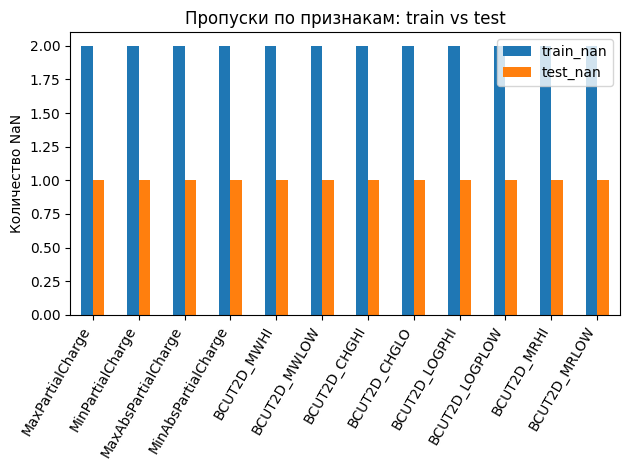

In [12]:
nan_train = X_train.isna().sum()
nan_test = X_test.isna().sum()

nan_cmp = pd.DataFrame({
    "train_nan": nan_train,
    "test_nan": nan_test
})

nan_cmp = nan_cmp[(nan_cmp["train_nan"] > 0) | (nan_cmp["test_nan"] > 0)]
plt.figure(figsize=(12, 4), dpi=300)
ax = nan_cmp.sort_values("train_nan", ascending=False).plot(kind="bar")
ax.set_title("Пропуски по признакам: train vs test")
ax.set_ylabel("Количество NaN")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

Посчитаем общее количество пропусков (`NaN`) в каждом датафрейме:
- `X_train.isna()` -> таблица `True/False`, где `True` = ячейка с `NaN`
- `.sum()` (первый) -> сколько `NaN` в каждом столбце
- `.sum()` (второй) -> сумма по всем столбцам, то есть общее число `NaN` в таблице

In [13]:
print("NaN в X_train:", X_train.isna().sum().sum())
print("NaN в y_train:", y_train.isna().sum().sum())
print("NaN в X_test :", X_test.isna().sum().sum())

NaN в X_train: 24
NaN в y_train: 0
NaN в X_test : 12


In [14]:
nan_by_col = X_train.isna().sum()

print(nan_by_col[nan_by_col > 0].sort_values(ascending=False).head(20))

MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64


In [15]:
nan_by_col = X_test.isna().sum()

print(nan_by_col[nan_by_col > 0].sort_values(ascending=False).head(20))

MaxPartialCharge       1
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
BCUT2D_MWHI            1
BCUT2D_MWLOW           1
BCUT2D_CHGHI           1
BCUT2D_CHGLO           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
BCUT2D_MRHI            1
BCUT2D_MRLOW           1
dtype: int64


Используем `SimpleImputer`, чтобы убрать немногочисленные пропуски в признаках без потери строк.

Стратегия `median` выбрана, потому что она устойчива к выбросам и хорошо подходит для числовых химических дескрипторов.

`fit` делаем только на `X_train`, чтобы не допустить утечки информации из теста.
К `X_test` применяем только `transform` с уже выученными значениями.

После преобразования возвращаем `DataFrame` с исходными `columns` и `index`, чтобы сохранить имена признаков и корректное выравнивание данных для обучения и предсказания.

In [16]:
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("NaN train:", X_train_imp.isna().sum().sum())
print("NaN test :", X_test_imp.isna().sum().sum())

NaN train: 0
NaN test : 0


## 2.5 Визуализация таргетов

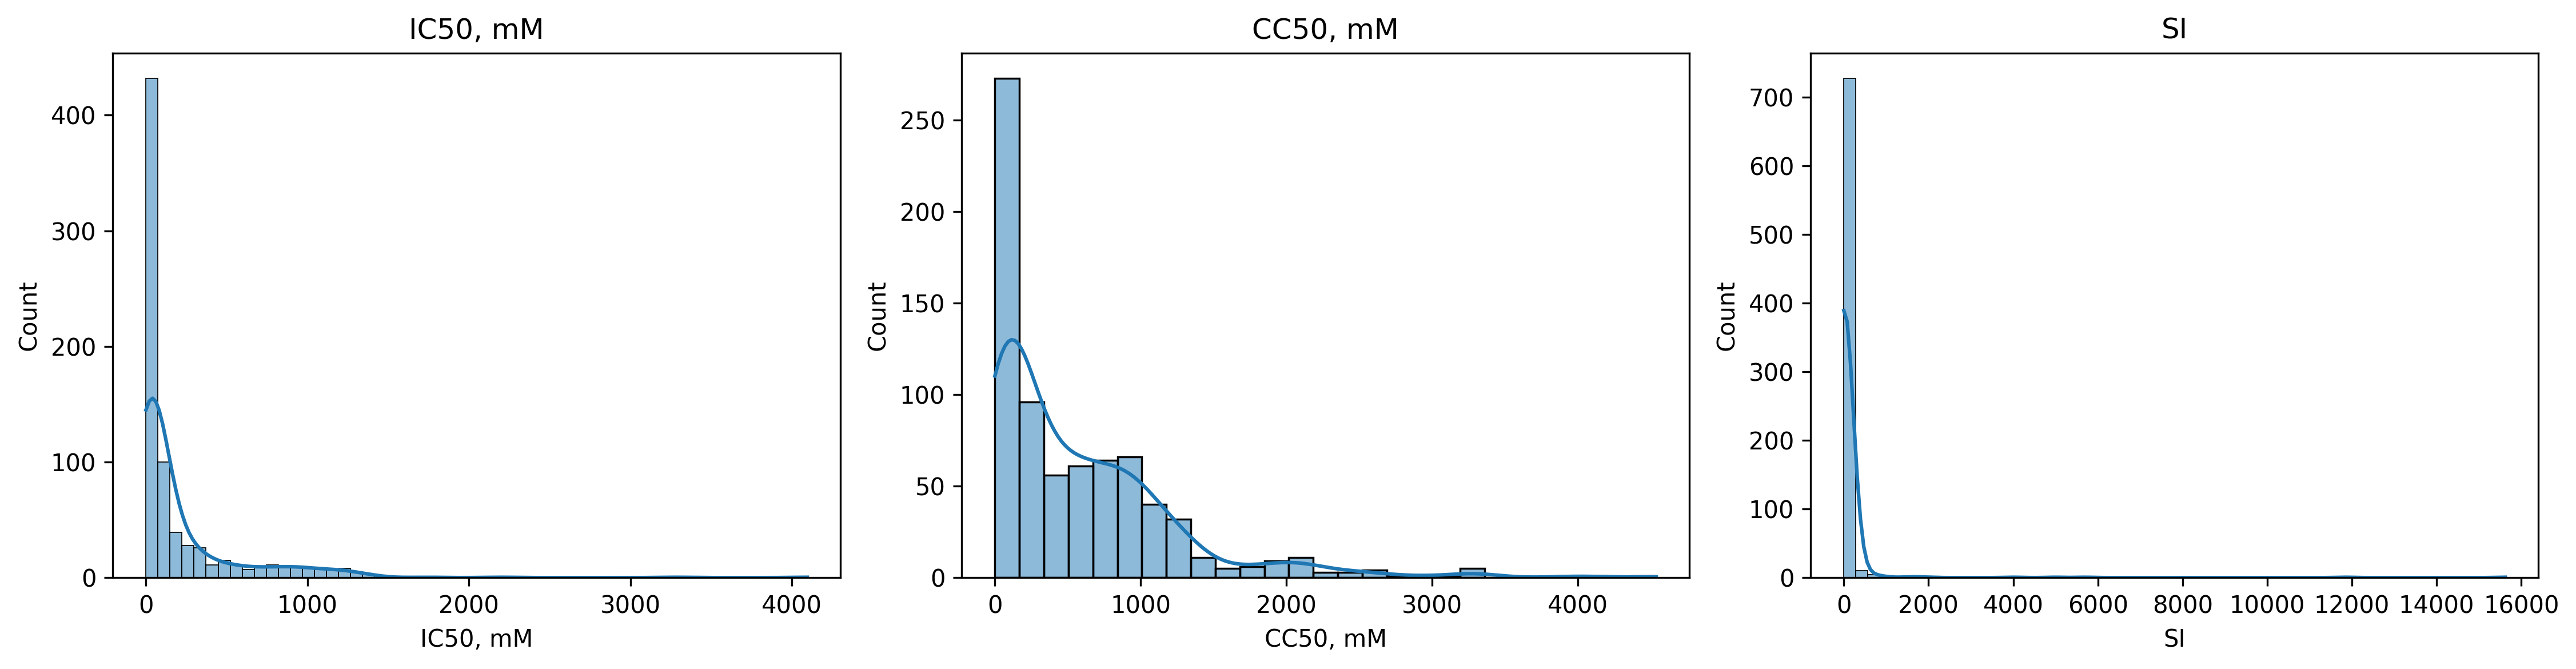

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=300)

for ax, col in zip(axes, ["IC50, mM", "CC50, mM", "SI"]):
    sns.histplot(train[col], kde=True, ax=ax)
    ax.set_title(col)
    
plt.tight_layout()
plt.show()

Распределения IC50, CC50, SI имеют выраженную правостороннюю асимметрию и длинные хвосты, поэтому для стабилизации обучения целесообразно использовать логарифмирование таргетов (`log1p`) перед обучением и обратное преобразование при формировании предсказаний.

Логарифмируем таргеты и визуализируем повторно:

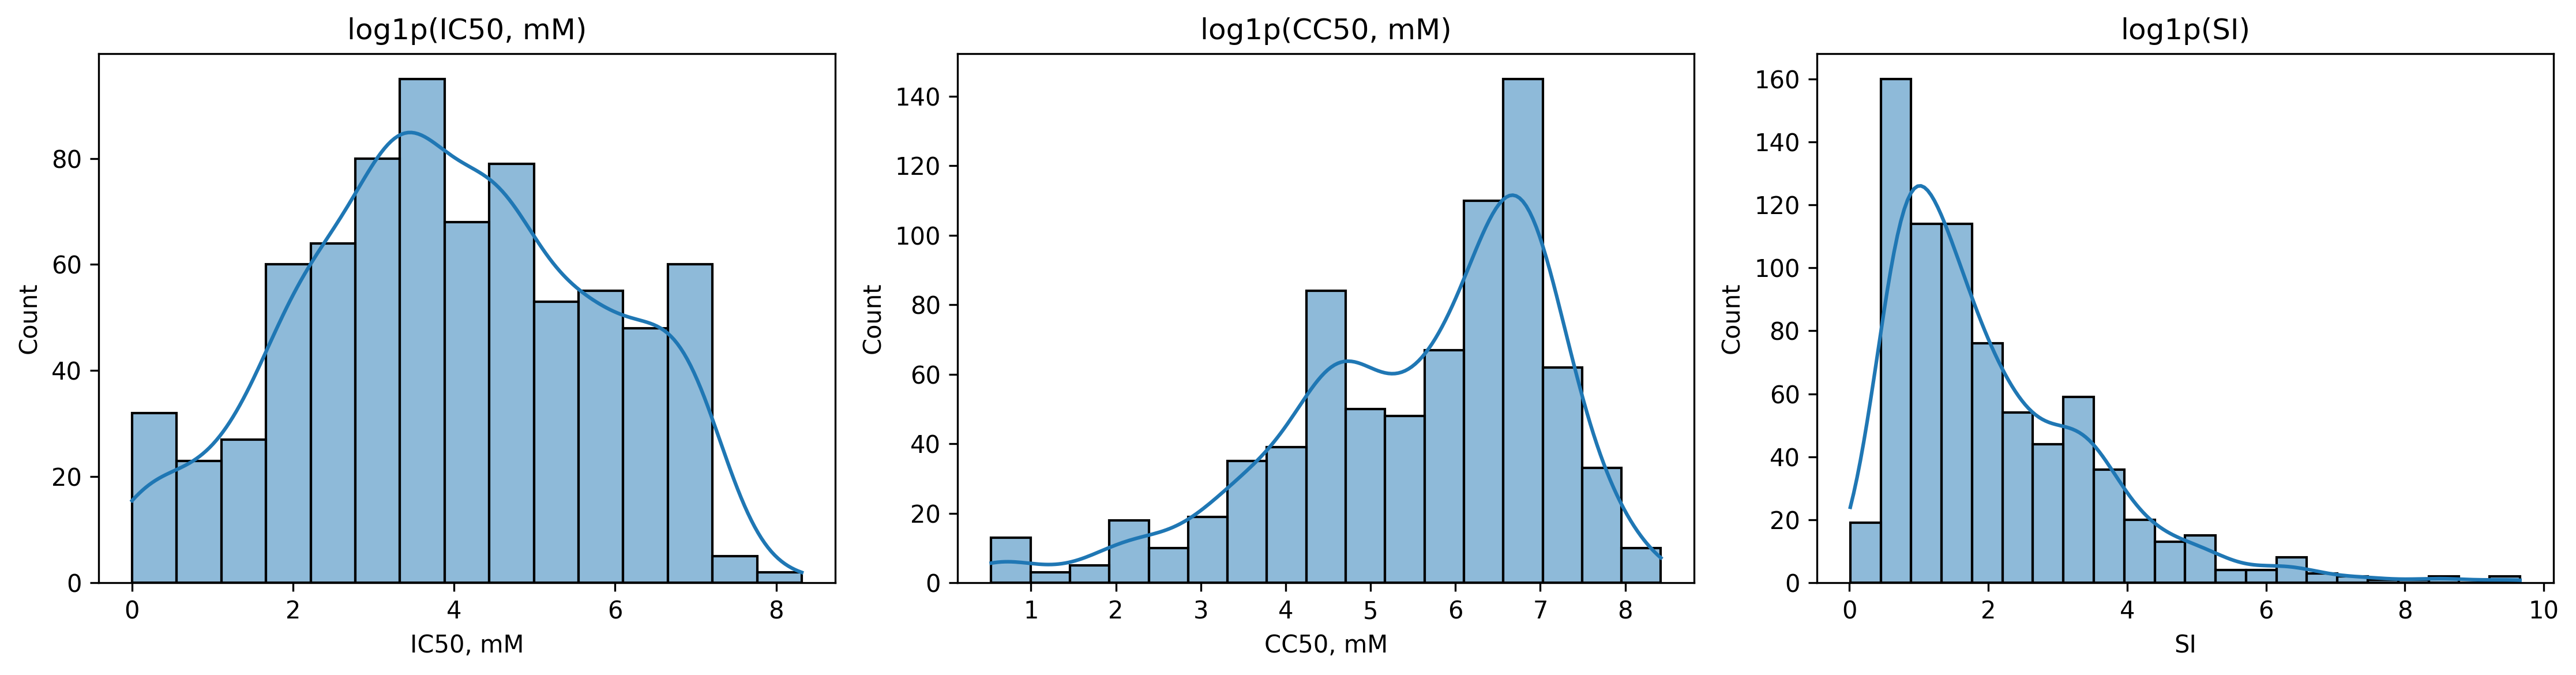

In [18]:
y_train_log = np.log1p(y_train)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=300)
for ax, col in zip(axes, y_train_log.columns):
    sns.histplot(y_train_log[col], kde=True, ax=ax)
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

После логарифмирования целевые распределения стали менее асимметричными, что снижает влияние длинных хвостов.

## 2.6 Проверка выбросов по таргетам (IQR)

In [19]:
def iqr_outlier_share(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean()

for c in y_train.columns:
    print(c, "| доля выбросов =", round(iqr_outlier_share(y_train[c]), 4))

IC50, mM | доля выбросов = 0.1425
CC50, mM | доля выбросов = 0.0426
SI | доля выбросов = 0.1212


Доля выбросов по `IQR` для `IC50` и `SI` заметная, поэтому вместо удаления объектов выбран подход обучения в лог-шкале (`log1p`) с обратным преобразованием предсказаний (`expm1`).

Почему:
- при `log1p` большие значения сжимаются сильнее малых;
- модель обучается на более “ровной” цели;
- экстремальные объекты меньше перетягивают обучение на себя.

# 3. Подбор модели

In [20]:
TARGET_COLS = ["IC50, mM", "CC50, mM", "SI"]

def comp_score(y_true, y_pred):
    # метрика соревнования: средний RMSE по 3 таргетам
    rmses = []
    for i in range(3):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        rmses.append(rmse)
    return float(np.mean(rmses))

In [21]:
def cv_catboost(X, y, use_log=False, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = []
    for tr_idx, va_idx in kf.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        if use_log:
            y_tr_fit = np.log1p(y_tr)
        else:
            y_tr_fit = y_tr.copy()
        preds_va = np.zeros((len(va_idx), 3), dtype=float)
        for j, col in enumerate(TARGET_COLS):
            model = CatBoostRegressor(
                iterations=1200,
                learning_rate=0.03,
                depth=6,
                loss_function="RMSE",
                eval_metric="RMSE",
                random_seed=42,
                verbose=False
            )
            model.fit(X_tr, y_tr_fit[col])
            p = model.predict(X_va)
            if use_log:
                p = np.expm1(p)
            preds_va[:, j] = p
        score = comp_score(y_va.values, preds_va)
        scores.append(score)
    return np.mean(scores), np.std(scores)

In [22]:
# Честный CV: CatBoost умеет работать с NaN, поэтому используем исходные X_train без глобального imputer.
raw_mean, raw_std = cv_catboost(X_train, y_train, use_log=False)
log_mean, log_std = cv_catboost(X_train, y_train, use_log=True)

print(f"RAW  CV: {raw_mean:.5f} ± {raw_std:.5f}")
print(f"LOG  CV: {log_mean:.5f} ± {log_std:.5f}")

use_log_best = log_mean < raw_mean

print("Выбран режим:", "log1p" if use_log_best else "raw")

RAW  CV: 485.96059 ± 138.13081
LOG  CV: 474.53468 ± 165.97613
Выбран режим: log1p


# 4. Финальное обучение на всем train и предсказание test

Для снижения вариативности, связанной со стохастичностью обучения `CatBoost`, применено усреднение предсказаний нескольких моделей с разными `random_seed` (seed ensemble). 

Такой подход уменьшает дисперсию и повышает устойчивость качества на тестовой выборке без изменения признакового пространства и архитектуры модели.

In [23]:
seeds = [42, 2024, 7]
preds_test = np.zeros((len(X_test), 3), dtype=float)

for seed in seeds:
    preds_seed = np.zeros((len(X_test), 3), dtype=float)

    for j, col in enumerate(TARGET_COLS):
        y_fit = np.log1p(y_train[col]) if use_log_best else y_train[col]

        model = CatBoostRegressor(
            iterations=1200,
            learning_rate=0.03,
            depth=6,
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=seed,
            verbose=False
        )
        model.fit(X_train, y_fit)

        p = model.predict(X_test)
        if use_log_best:
            p = np.expm1(p)

        preds_seed[:, j] = p

    preds_test += preds_seed

preds_test /= len(seeds)

In [24]:
submission = sample_submission.copy()
submission["IC50"] = preds_test[:, 0]
submission["CC50"] = preds_test[:, 1]
submission["SI"] = preds_test[:, 2]
submission.to_csv("submission.csv", index=False)

display(submission.head())
display(submission.shape)

,index,IC50,CC50,SI
0,0,82.524586,165.817842,4.875062
1,1,69.455244,371.048898,4.976138
2,2,42.428829,263.364448,6.468059
3,3,141.007234,199.273901,3.111815
4,4,170.605025,223.927101,1.730551


(250, 4)

# 5. Target-wise тюнинг CatBoost

Пробуем улучшить качество без масштабных изменений: подбираем гиперпараметры отдельно для каждого таргета (`IC50`, `CC50`, `SI`).

### Этап 1 (быстрый скрининг)

Сначала быстро отсеиваем слабые конфигурации: используем 3-fold CV, небольшой набор `iterations` и раннюю остановку (`early stopping`).

Цель этапа — получить по каждому таргету небольшой список лучших кандидатов, не тратя время на полный перебор в 5-fold.

In [25]:
from itertools import product


def cv_rmse_single_target(X, y_col, params, use_log=True, n_splits=3, random_state=42, seed=42, use_early_stopping=True):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_scores = []

    for tr_idx, va_idx in kf.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y_col.iloc[tr_idx], y_col.iloc[va_idx]

        y_tr_fit = np.log1p(y_tr) if use_log else y_tr
        y_va_fit = np.log1p(y_va) if use_log else y_va

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=seed,
            verbose=False,
            **params,
        )

        if use_early_stopping:
            model.fit(
                X_tr,
                y_tr_fit,
                eval_set=(X_va, y_va_fit),
                use_best_model=True,
                early_stopping_rounds=100,
            )
        else:
            model.fit(X_tr, y_tr_fit)

        pred_va = model.predict(X_va)
        if use_log:
            pred_va = np.expm1(pred_va)

        rmse = np.sqrt(mean_squared_error(y_va, pred_va))
        fold_scores.append(rmse)

    return float(np.mean(fold_scores)), float(np.std(fold_scores))


# Быстрая сетка для первичного скрининга
fast_param_grid = {
    "iterations": [600, 1000],
    "depth": [5, 6],
    "learning_rate": [0.02, 0.03],
    "l2_leaf_reg": [5, 7, 9],
}

fast_param_combinations = [
    dict(zip(fast_param_grid.keys(), values))
    for values in product(*fast_param_grid.values())
]

# Для каждого таргета сохраняем top-3 конфигурации после быстрого скрининга
top_candidates_by_target = {}

for target_col in TARGET_COLS:
    print(f"\n=== Этап 1: быстрый подбор для {target_col} ===")
    results = []

    for params in fast_param_combinations:
        mean_rmse, std_rmse = cv_rmse_single_target(
            X_train,
            y_train[target_col],
            params=params,
            use_log=use_log_best,
            n_splits=3,
            random_state=42,
            seed=42,
            use_early_stopping=True,
        )
        results.append((mean_rmse, std_rmse, params))

    results = sorted(results, key=lambda x: x[0])
    top_candidates_by_target[target_col] = results[:3]

    best_mean, best_std, best_params = results[0]
    print(f"Лучший на этапе 1: {best_mean:.5f} ± {best_std:.5f}")
    print(f"Параметры: {best_params}")

top_candidates_by_target


=== Этап 1: быстрый подбор для IC50, mM ===
Лучший на этапе 1: 349.36596 ± 16.50163
Параметры: {'iterations': 1000, 'depth': 5, 'learning_rate': 0.02, 'l2_leaf_reg': 7}

=== Этап 1: быстрый подбор для CC50, mM ===
Лучший на этапе 1: 514.54475 ± 35.20389
Параметры: {'iterations': 600, 'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 7}

=== Этап 1: быстрый подбор для SI ===
Лучший на этапе 1: 673.18478 ± 398.50127
Параметры: {'iterations': 1000, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 5}


{'IC50, mM': [(349.3659596851409,
   16.501625758318685,
   {'iterations': 1000, 'depth': 5, 'learning_rate': 0.02, 'l2_leaf_reg': 7}),
  (349.4940493930945,
   17.085960655541808,
   {'iterations': 600, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 5}),
  (349.4940493930945,
   17.085960655541808,
   {'iterations': 1000, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 5})],
 'CC50, mM': [(514.5447458047793,
   35.20389446913973,
   {'iterations': 600, 'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 7}),
  (514.5447458047793,
   35.20389446913973,
   {'iterations': 1000, 'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 7}),
  (516.6335725754135,
   35.924619383422325,
   {'iterations': 600, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 5})],
 'SI': [(673.1847778037139,
   398.5012728136828,
   {'iterations': 1000, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 5}),
  (673.2342708315551,
   398.13145273743623,
   {'iterations': 1000, 'depth': 5, 'learning_rate': 0.03, 'l

### Этап 2 (точное подтверждение)

Теперь проверяем только top-3 кандидата для каждого таргета на более строгом режиме (`5-fold`).

Цель этапа — сохранить качество полного подбора, но сильно сократить время вычислений.

По результатам второго этапа получаем финальные `best_params_by_target`, которые используем в обучении финальной модели и сабмита.

In [26]:
best_params_by_target = {}

for target_col in TARGET_COLS:
    print(f"\n=== Этап 2: подтверждение для {target_col} ===")

    best_score = np.inf
    best_std = None
    best_params = None

    for _, _, params in top_candidates_by_target[target_col]:
        mean_rmse, std_rmse = cv_rmse_single_target(
            X_train,
            y_train[target_col],
            params=params,
            use_log=use_log_best,
            n_splits=5,
            random_state=42,
            seed=42,
            use_early_stopping=True,
        )

        if mean_rmse < best_score:
            best_score = mean_rmse
            best_std = std_rmse
            best_params = params

    best_params_by_target[target_col] = best_params
    print(f"Итоговый лучший RMSE: {best_score:.5f} ± {best_std:.5f}")
    print(f"Итоговые параметры: {best_params}")

best_params_by_target


=== Этап 2: подтверждение для IC50, mM ===
Итоговый лучший RMSE: 348.46365 ± 62.38753
Итоговые параметры: {'iterations': 600, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 5}

=== Этап 2: подтверждение для CC50, mM ===
Итоговый лучший RMSE: 505.12091 ± 50.14893
Итоговые параметры: {'iterations': 1000, 'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 7}

=== Этап 2: подтверждение для SI ===
Итоговый лучший RMSE: 603.48253 ± 498.75915
Итоговые параметры: {'iterations': 1000, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 9}


{'IC50, mM': {'iterations': 600,
  'depth': 5,
  'learning_rate': 0.03,
  'l2_leaf_reg': 5},
 'CC50, mM': {'iterations': 1000,
  'depth': 6,
  'learning_rate': 0.03,
  'l2_leaf_reg': 7},
 'SI': {'iterations': 1000,
  'depth': 5,
  'learning_rate': 0.03,
  'l2_leaf_reg': 9}}

# 6. Стабилизация SI (точечный эксперимент с RepeatedKFold)

Переходим к более точечной проверке: оставляем `loss=RMSE`, а стабильность оценки повышаем через повторяющиеся разбиения `RepeatedKFold`.

Попытка стабилизации `SI` через `StratifiedKFold` и robust-loss (`MAE/Huber`) не дала прироста.

Поэтому используем более точечный вариант: подбор параметров `SI` через `RepeatedKFold (5x3)` и сравниваем его с текущим baseline по CV и leaderboard.

# 7. Feature Importance + SHAP и отбор top-k признаков

Проверяем гипотезу, что часть признаков шумит, и пытаемся улучшить качество через отбор наиболее информативных фич.

Сначала считаем важности признаков по CatBoost для каждого таргета и дополнительно проверяем объяснимость через SHAP для `SI`.

Top-15 SHAP признаков для SI:


,mean_abs_shap
FractionCSP3,0.079198
FpDensityMorgan3,0.059469
SMR_VSA7,0.057231
NumSaturatedHeterocycles,0.047861
RingCount,0.041532
BCUT2D_MRLOW,0.038070
EState_VSA2,0.032308
NumSaturatedCarbocycles,0.030496
BCUT2D_LOGPHI,0.029255
EState_VSA5,0.028153


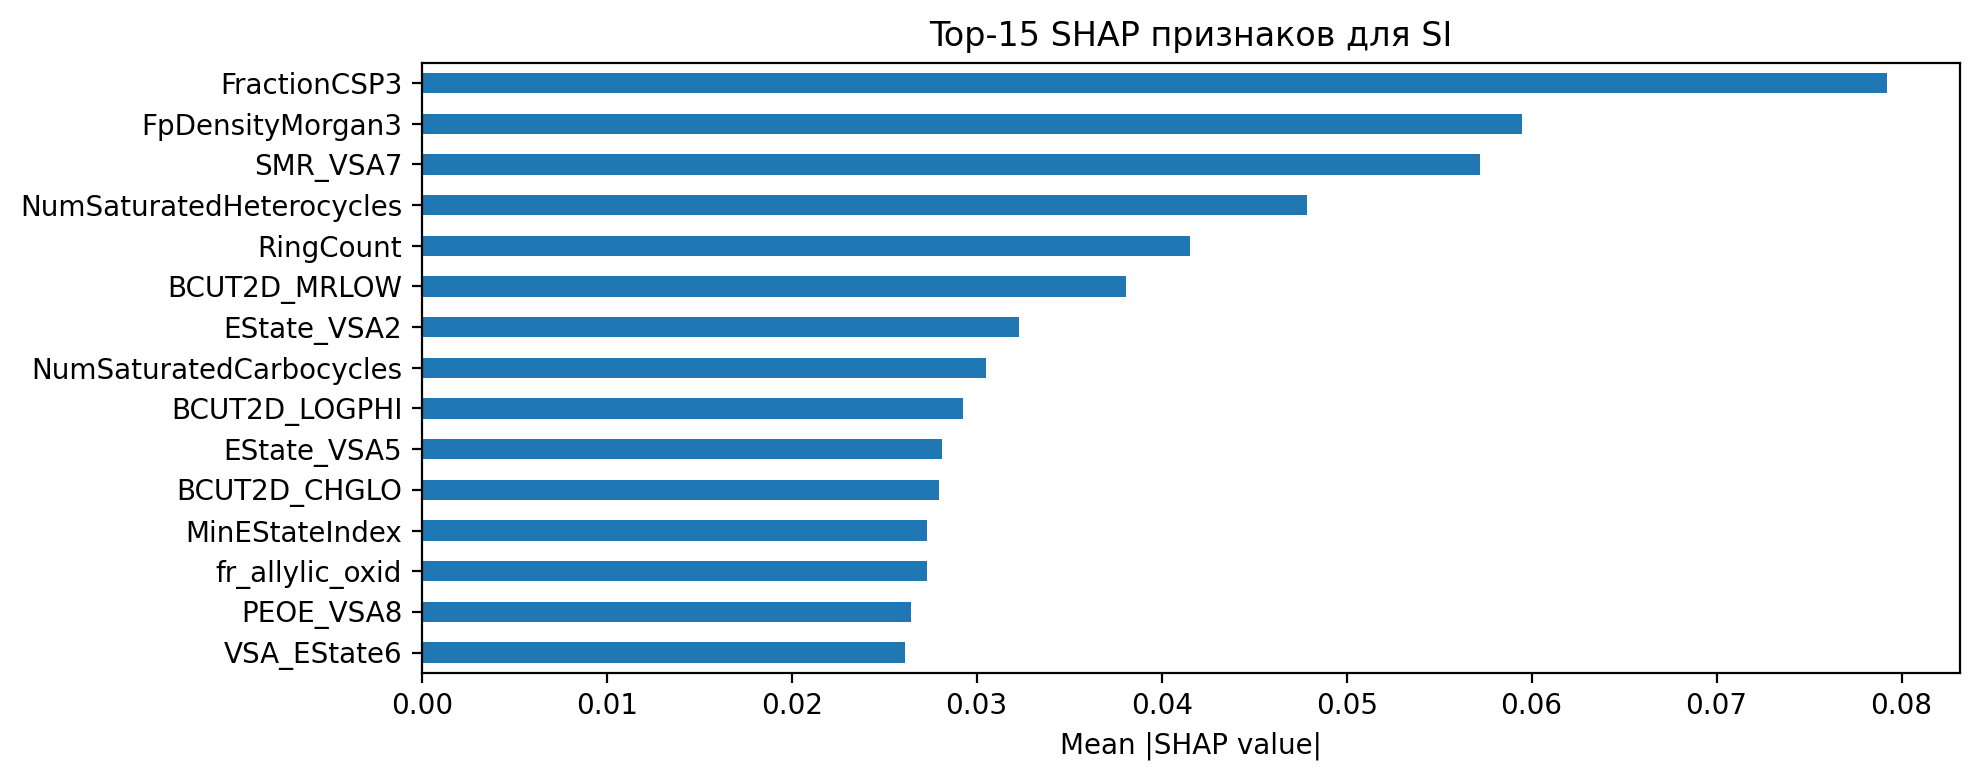

Подготовлен ранжированный список признаков для top-k отбора.


In [27]:
active_params = best_params_by_target

feature_importance_df = pd.DataFrame(index=X_train.columns)

for col in TARGET_COLS:
    y_fit = np.log1p(y_train[col]) if use_log_best else y_train[col]

    model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        verbose=False,
        **active_params[col],
    )
    model.fit(X_train, y_fit)

    fi = model.get_feature_importance()
    feature_importance_df[col] = fi

# Усредняем ранги важности между таргетами, чтобы получить общий список признаков.
rank_mean = feature_importance_df.rank(ascending=False).mean(axis=1)
feature_order = rank_mean.sort_values().index.tolist()

# SHAP-анализ для SI (на подвыборке для скорости).
si_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=False,
    **active_params["SI"],
)
si_y_fit = np.log1p(y_train["SI"]) if use_log_best else y_train["SI"]
si_model.fit(X_train, si_y_fit)

from catboost import Pool

shap_sample = X_train.sample(n=min(200, len(X_train)), random_state=42)
shap_pool = Pool(shap_sample)
shap_values = si_model.get_feature_importance(data=shap_pool, type="ShapValues")
shap_abs_mean = np.abs(shap_values[:, :-1]).mean(axis=0)

shap_importance_si = (
    pd.Series(shap_abs_mean, index=X_train.columns)
    .sort_values(ascending=False)
)

print("Top-15 SHAP признаков для SI:")
display(shap_importance_si.head(15).to_frame("mean_abs_shap"))

plt.figure(figsize=(10, 4), dpi=200)
shap_importance_si.head(15).iloc[::-1].plot(kind="barh")
plt.title("Top-15 SHAP признаков для SI")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

print("Подготовлен ранжированный список признаков для top-k отбора.")

Теперь проверяем несколько вариантов `top-k` по CV, выбираем лучший `k` и обучаем финальные модели только на этих признаках.

In [28]:
def cv_catboost_topk(X, y, params_by_target, use_log, selected_features, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = []

    X_sel = X[selected_features]

    for tr_idx, va_idx in kf.split(X_sel):
        X_tr, X_va = X_sel.iloc[tr_idx], X_sel.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        preds_va = np.zeros((len(va_idx), 3), dtype=float)

        for j, col in enumerate(TARGET_COLS):
            y_tr_fit = np.log1p(y_tr[col]) if use_log else y_tr[col]

            model = CatBoostRegressor(
                loss_function="RMSE",
                eval_metric="RMSE",
                random_seed=42,
                verbose=False,
                **params_by_target[col],
            )
            model.fit(X_tr, y_tr_fit)

            p = model.predict(X_va)
            if use_log:
                p = np.expm1(p)

            preds_va[:, j] = np.clip(p, 0, None)

        scores.append(comp_score(y_va.values, preds_va))

    return float(np.mean(scores)), float(np.std(scores))


candidate_ks = [60, 90, 120, 150, 180, len(feature_order)]
candidate_ks = sorted(set([k for k in candidate_ks if 10 <= k <= len(feature_order)]))

topk_results = []
for k in candidate_ks:
    selected = feature_order[:k]
    mean_score, std_score = cv_catboost_topk(
        X_train,
        y_train,
        params_by_target=active_params,
        use_log=use_log_best,
        selected_features=selected,
        n_splits=5,
        random_state=42,
    )
    topk_results.append((k, mean_score, std_score))
    print(f"top-{k}: {mean_score:.5f} ± {std_score:.5f}")

best_k, best_k_score, best_k_std = min(topk_results, key=lambda x: x[1])
selected_features_best = feature_order[:best_k]
print(f"\nЛучший k: {best_k}, CV: {best_k_score:.5f} ± {best_k_std:.5f}")

seeds_topk = [42, 2024, 7, 1337, 3407]
preds_test_topk = np.zeros((len(X_test), 3), dtype=float)

X_train_best = X_train[selected_features_best]
X_test_best = X_test[selected_features_best]

for seed in seeds_topk:
    preds_seed = np.zeros((len(X_test_best), 3), dtype=float)

    for j, col in enumerate(TARGET_COLS):
        y_fit = np.log1p(y_train[col]) if use_log_best else y_train[col]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=seed,
            verbose=False,
            **active_params[col],
        )
        model.fit(X_train_best, y_fit)

        p = model.predict(X_test_best)
        if use_log_best:
            p = np.expm1(p)

        preds_seed[:, j] = np.clip(p, 0, None)

    preds_test_topk += preds_seed

preds_test_topk /= len(seeds_topk)

submission_topk = sample_submission.copy()
submission_topk["IC50"] = preds_test_topk[:, 0]
submission_topk["CC50"] = preds_test_topk[:, 1]
submission_topk["SI"] = preds_test_topk[:, 2]
submission_topk.to_csv("submission_topk.csv", index=False)

print(f"Сохранен файл submission_topk.csv с top-{best_k} признаками")
display(submission_topk.head())
display(submission_topk.shape)

top-60: 477.81984 ± 167.55511
top-90: 475.94914 ± 167.08382
top-120: 475.85600 ± 166.87956
top-150: 475.98954 ± 166.70629
top-180: 478.16309 ± 167.12811
top-186: 476.27841 ± 169.15039

Лучший k: 120, CV: 475.85600 ± 166.87956
Сохранен файл submission_topk.csv с top-120 признаками


,index,IC50,CC50,SI
0,0,73.258294,214.336471,4.138099
1,1,92.167730,354.164818,3.950963
2,2,40.768194,256.005257,6.369742
3,3,112.371389,184.790858,3.703951
4,4,139.680811,256.810393,1.999368


(250, 4)

# 8. Принципиально новый трек: PCA + Ridge + OOF-blend

Пробуем другой класс моделей: линейную регрессию на PCA-компонентах и затем блендим её с CatBoost по OOF, чтобы объединить разные типы ошибок.

Шаг 1: строим OOF-предсказания для CatBoost и для `PCA + Ridge` на одинаковых фолдах. Это нужно для честного сравнения и дальнейшего подбора весов блендинга.

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

# Используем top-k признаки, если они уже вычислены в ноутбуке.
feature_cols_exp = selected_features_best if "selected_features_best" in globals() else X_train.columns.tolist()
X_exp_train = X_train[feature_cols_exp]
X_exp_test = X_test[feature_cols_exp]

active_params = best_params_by_target_si_stable if "best_params_by_target_si_stable" in globals() else best_params_by_target

# Безопасные настройки для PCA+Ridge (чтобы избежать взрыва после expm1).
pca_n_components = min(60, X_exp_train.shape[1])
ridge_alpha_grid = [3.0, 10.0, 30.0, 100.0]
pca_ridge_use_log = False
log_clip_max = 12.0

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_cat = np.zeros((len(X_exp_train), 3), dtype=float)
oof_pca_ridge = np.zeros((len(X_exp_train), 3), dtype=float)

test_cat = np.zeros((len(X_exp_test), 3), dtype=float)
test_pca_ridge = np.zeros((len(X_exp_test), 3), dtype=float)

seeds_cat = [42, 2024, 7]

for tr_idx, va_idx in kf.split(X_exp_train):
    X_tr, X_va = X_exp_train.iloc[tr_idx], X_exp_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    fold_va_cat = np.zeros((len(va_idx), 3), dtype=float)
    fold_te_cat = np.zeros((len(X_exp_test), 3), dtype=float)

    fold_va_pr = np.zeros((len(va_idx), 3), dtype=float)
    fold_te_pr = np.zeros((len(X_exp_test), 3), dtype=float)

    for seed in seeds_cat:
        seed_va_cat = np.zeros((len(va_idx), 3), dtype=float)
        seed_te_cat = np.zeros((len(X_exp_test), 3), dtype=float)

        for j, col in enumerate(TARGET_COLS):
            y_tr_fit = np.log1p(y_tr[col]) if use_log_best else y_tr[col]

            cat_model = CatBoostRegressor(
                loss_function="RMSE",
                eval_metric="RMSE",
                random_seed=seed,
                verbose=False,
                **active_params[col],
            )
            cat_model.fit(X_tr, y_tr_fit)

            p_va = cat_model.predict(X_va)
            p_te = cat_model.predict(X_exp_test)

            if use_log_best:
                p_va = np.expm1(np.clip(p_va, 0, log_clip_max))
                p_te = np.expm1(np.clip(p_te, 0, log_clip_max))

            seed_va_cat[:, j] = np.clip(p_va, 0, None)
            seed_te_cat[:, j] = np.clip(p_te, 0, None)

        fold_va_cat += seed_va_cat
        fold_te_cat += seed_te_cat

    fold_va_cat /= len(seeds_cat)
    fold_te_cat /= len(seeds_cat)

    # PCA + Ridge (другая индуктивная гипотеза), подбираем alpha на валидационном фолде.
    for j, col in enumerate(TARGET_COLS):
        y_tr_fit = np.log1p(y_tr[col]) if pca_ridge_use_log else y_tr[col]
        y_va_true = y_va[col].values

        best_alpha = None
        best_rmse = np.inf
        best_p_va = None
        best_p_te = None

        for ridge_alpha in ridge_alpha_grid:
            pr_model = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=pca_n_components, random_state=42)),
                ("ridge", Ridge(alpha=ridge_alpha)),
            ])
            pr_model.fit(X_tr, y_tr_fit)

            p_va = pr_model.predict(X_va)
            p_te = pr_model.predict(X_exp_test)

            if pca_ridge_use_log:
                p_va = np.expm1(np.clip(p_va, 0, log_clip_max))
                p_te = np.expm1(np.clip(p_te, 0, log_clip_max))

            p_va = np.clip(p_va, 0, None)
            p_te = np.clip(p_te, 0, None)

            rmse = np.sqrt(mean_squared_error(y_va_true, p_va))
            if rmse < best_rmse:
                best_rmse = rmse
                best_alpha = ridge_alpha
                best_p_va = p_va
                best_p_te = p_te

        fold_va_pr[:, j] = best_p_va
        fold_te_pr[:, j] = best_p_te

    oof_cat[va_idx] = fold_va_cat
    oof_pca_ridge[va_idx] = fold_va_pr

    test_cat += fold_te_cat
    test_pca_ridge += fold_te_pr

# усредняем test-предсказания по фолдам
test_cat /= 5
test_pca_ridge /= 5

print(f"OOF CatBoost score: {comp_score(y_train.values, oof_cat):.5f}")
print(f"OOF PCA+Ridge score: {comp_score(y_train.values, oof_pca_ridge):.5f}")

OOF CatBoost score: 538.92183
OOF PCA+Ridge score: 561.72174


Шаг 2: подбираем веса блендинга `CatBoost + PCA+Ridge` по OOF отдельно для каждого таргета и формируем новый сабмит.

In [31]:
best_weights_cp = {}

for j, col in enumerate(TARGET_COLS):
    y_true = y_train[col].values
    best_rmse = np.inf
    best_w = None

    for w_cat in np.linspace(0, 1, 21):
        pred = w_cat * oof_cat[:, j] + (1 - w_cat) * oof_pca_ridge[:, j]
        rmse = np.sqrt(mean_squared_error(y_true, pred))

        if rmse < best_rmse:
            best_rmse = rmse
            best_w = float(w_cat)

    best_weights_cp[col] = best_w
    print(f"{col}: best_w_cat={best_w:.2f}, best_w_pca_ridge={1-best_w:.2f}, OOF_RMSE={best_rmse:.5f}")


oof_blend_cp = np.column_stack([
    best_weights_cp[col] * oof_cat[:, j] + (1 - best_weights_cp[col]) * oof_pca_ridge[:, j]
    for j, col in enumerate(TARGET_COLS)
])
print(f"OOF Blend score (CatBoost + PCA+Ridge): {comp_score(y_train.values, oof_blend_cp):.5f}")

preds_test_blend_cp = np.column_stack([
    best_weights_cp[col] * test_cat[:, j] + (1 - best_weights_cp[col]) * test_pca_ridge[:, j]
    for j, col in enumerate(TARGET_COLS)
])

submission_stack_pca = sample_submission.copy()
submission_stack_pca["IC50"] = preds_test_blend_cp[:, 0]
submission_stack_pca["CC50"] = preds_test_blend_cp[:, 1]
submission_stack_pca["SI"] = preds_test_blend_cp[:, 2]
submission_stack_pca.to_csv("submission_stack_pca_ridge.csv", index=False)

print("Сохранен submission_stack_pca_ridge.csv")
display(submission_stack_pca.head())
display(submission_stack_pca.shape)
best_weights_cp

IC50, mM: best_w_cat=1.00, best_w_pca_ridge=0.00, OOF_RMSE=347.80313
CC50, mM: best_w_cat=1.00, best_w_pca_ridge=0.00, OOF_RMSE=487.77943
SI: best_w_cat=1.00, best_w_pca_ridge=0.00, OOF_RMSE=781.18294
OOF Blend score (CatBoost + PCA+Ridge): 538.92183
Сохранен submission_stack_pca_ridge.csv


,index,IC50,CC50,SI
0,0,70.025702,215.202336,4.182315
1,1,84.937807,336.861545,3.916645
2,2,39.567891,258.063379,6.339766
3,3,101.132838,200.941390,3.942144
4,4,135.769809,254.618048,2.124618


(250, 4)

{'IC50, mM': 1.0, 'CC50, mM': 1.0, 'SI': 1.0}

# 9. SI Quantile Target Transform

Пробуем точечный эксперимент для самого шумного таргета `SI`: обучаем модель не на исходном `SI`, а на его квантильном нормальном преобразовании и затем делаем обратное преобразование предсказаний.

Считаем OOF и test-предсказания: для `IC50/CC50` оставляем текущую схему, для `SI` применяем `QuantileTransformer(output_distribution='normal')` внутри каждого фолда (без утечки).

In [ ]:
from sklearn.preprocessing import QuantileTransformer

active_params = best_params_by_target_si_stable if "best_params_by_target_si_stable" in globals() else best_params_by_target
feature_cols_qt = selected_features_best if "selected_features_best" in globals() else X_train.columns.tolist()

X_qt_train = X_train[feature_cols_qt]
X_qt_test = X_test[feature_cols_qt]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
seeds_qt = [42, 2024, 7]

oof_qt = np.zeros((len(X_qt_train), 3), dtype=float)
test_qt = np.zeros((len(X_qt_test), 3), dtype=float)

for tr_idx, va_idx in kf.split(X_qt_train):
    X_tr, X_va = X_qt_train.iloc[tr_idx], X_qt_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    fold_va = np.zeros((len(va_idx), 3), dtype=float)
    fold_te = np.zeros((len(X_qt_test), 3), dtype=float)

    for seed in seeds_qt:
        seed_va = np.zeros((len(va_idx), 3), dtype=float)
        seed_te = np.zeros((len(X_qt_test), 3), dtype=float)

        for j, col in enumerate(TARGET_COLS):
            if col in ["IC50, mM", "CC50, mM"]:
                y_tr_fit = np.log1p(y_tr[col])

                model = CatBoostRegressor(
                    loss_function="RMSE",
                    eval_metric="RMSE",
                    random_seed=seed,
                    verbose=False,
                    **active_params[col],
                )
                model.fit(X_tr, y_tr_fit)

                p_va = np.expm1(np.clip(model.predict(X_va), 0, 12))
                p_te = np.expm1(np.clip(model.predict(X_qt_test), 0, 12))

            else:
                # Для SI используем квантильное преобразование таргета в нормальное пространство.
                qt = QuantileTransformer(
                    n_quantiles=min(200, len(y_tr)),
                    output_distribution="normal",
                    random_state=42,
                )
                y_tr_si = y_tr[[col]].values
                y_tr_fit = qt.fit_transform(y_tr_si).ravel()

                model = CatBoostRegressor(
                    loss_function="RMSE",
                    eval_metric="RMSE",
                    random_seed=seed,
                    verbose=False,
                    **active_params[col],
                )
                model.fit(X_tr, y_tr_fit)

                p_va_z = model.predict(X_va).reshape(-1, 1)
                p_te_z = model.predict(X_qt_test).reshape(-1, 1)

                p_va = qt.inverse_transform(p_va_z).ravel()
                p_te = qt.inverse_transform(p_te_z).ravel()

            seed_va[:, j] = np.clip(p_va, 0, None)
            seed_te[:, j] = np.clip(p_te, 0, None)

        fold_va += seed_va
        fold_te += seed_te

    fold_va /= len(seeds_qt)
    fold_te /= len(seeds_qt)

    oof_qt[va_idx] = fold_va
    test_qt += fold_te

test_qt /= 5

print(f"OOF score (SI Quantile Transform): {comp_score(y_train.values, oof_qt):.5f}")

Сравниваем новый трек с текущим CatBoost baseline и, если OOF не хуже, формируем отдельный сабмит `submission_si_quantile.csv`.

In [ ]:
# Базовый OOF для сравнения (если его нет в текущем контексте)
if "oof_cat" not in globals():
    oof_cat = np.zeros((len(X_qt_train), 3), dtype=float)

    kf_base = KFold(n_splits=5, shuffle=True, random_state=42)
    for tr_idx, va_idx in kf_base.split(X_qt_train):
        X_tr, X_va = X_qt_train.iloc[tr_idx], X_qt_train.iloc[va_idx]
        y_tr = y_train.iloc[tr_idx]

        fold_va = np.zeros((len(va_idx), 3), dtype=float)
        for seed in seeds_qt:
            seed_va = np.zeros((len(va_idx), 3), dtype=float)
            for j, col in enumerate(TARGET_COLS):
                y_tr_fit = np.log1p(y_tr[col])
                model = CatBoostRegressor(
                    loss_function="RMSE",
                    eval_metric="RMSE",
                    random_seed=seed,
                    verbose=False,
                    **active_params[col],
                )
                model.fit(X_tr, y_tr_fit)
                p_va = np.expm1(np.clip(model.predict(X_va), 0, 12))
                seed_va[:, j] = np.clip(p_va, 0, None)
            fold_va += seed_va
        fold_va /= len(seeds_qt)
        oof_cat[va_idx] = fold_va

print(f"OOF CatBoost baseline: {comp_score(y_train.values, oof_cat):.5f}")
print(f"OOF SI Quantile track: {comp_score(y_train.values, oof_qt):.5f}")

submission_si_quantile = sample_submission.copy()
submission_si_quantile["IC50"] = test_qt[:, 0]
submission_si_quantile["CC50"] = test_qt[:, 1]
submission_si_quantile["SI"] = test_qt[:, 2]
submission_si_quantile.to_csv("submission_si_quantile.csv", index=False)

print("Сохранен submission_si_quantile.csv")
display(submission_si_quantile.head())
display(submission_si_quantile.shape)